<a href="https://colab.research.google.com/github/w-b-d/Ml-Project/blob/ACbranch/notebook/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Breast Cancer Detection**
**Team Members:**  
- Anghel Carrillo  
- Kristopher Church  
- Brianna Magallon  
- William Brady-Diaz  

**Date:** December 2025  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import glob
import random
import os

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Dense, BatchNormalization, Dropout, GlobalAveragePooling2D)

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import (train_test_split, GroupShuffleSplit)
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

%matplotlib inline


Extract IDC Breast Cancer Dataset into Colab Runtime

In [3]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/LeBromide/data/IDC_regular_ps50_idx5.zip"
!unzip -q "$zip_path" -d data/
print("Dataset extracted into /content/data/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace data/IDC_regular_ps50_idx5/10253/0/10253_idx5_x1001_y1001_class0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset extracted into /content/data/


Number of images found: 277524
Example image: data/IDC_regular_ps50_idx5/12821/1/12821_idx5_x1801_y951_class1.png


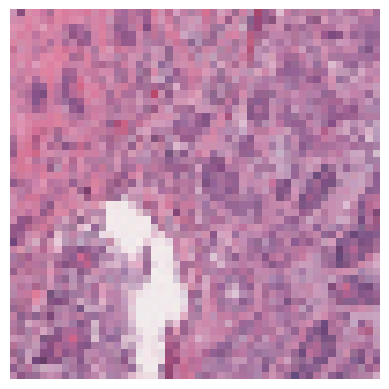

In [4]:

image_paths = glob.glob("data/IDC_regular_ps50_idx5/*/*/*.png")
print("Number of images found:", len(image_paths))


random_path = random.choice(image_paths)
print("Example image:", random_path)

img = cv2.imread(random_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

# Baseline Model




In [5]:
data = []

for path in image_paths:

    label = os.path.basename(os.path.dirname(path))

    patient_id = os.path.basename(os.path.dirname(os.path.dirname(path)))
    data.append([path, int(label), patient_id])

df = pd.DataFrame(data, columns=["filepath", "label", "patient_id"])


In [7]:
patients = df['patient_id'].unique()

# 2) Train–test split at patient level
train_pats, test_pats = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

# 3) Build train and test dataframes from those IDs
train_df_full = df[df['patient_id'].isin(train_pats)].reset_index(drop=True)
test_df       = df[df['patient_id'].isin(test_pats)].reset_index(drop=True)

# 4) Train–val split inside train patients
train_pats2, val_pats = train_test_split(
    train_pats,
    test_size=0.2,
    random_state=42
)

train_df = train_df_full[train_df_full['patient_id'].isin(train_pats2)].reset_index(drop=True)
val_df   = train_df_full[train_df_full['patient_id'].isin(val_pats)].reset_index(drop=True)

train_df['label'] = train_df['label'].astype(str)
val_df['label']   = val_df['label'].astype(str)
test_df['label']  = test_df['label'].astype(str)

y_train_numeric = train_df['label'].astype(int).values  # back to ints

classes = np.array([0, 1])
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_numeric
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weights)

Class weights: {0: 0.7045795059655948, 1: 1.7220187883435583}


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
batch_size = 128
target_size = (50, 50)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

Found 179641 validated image filenames belonging to 2 classes.
Found 46509 validated image filenames belonging to 2 classes.
Found 51374 validated image filenames belonging to 2 classes.


In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=5)

inputs = Input(shape=(50, 50, 3))

x = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform',
           padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform',
           padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)


x = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform',
           padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform',
           padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)


x = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform',
           padding='same')(x)

x = GlobalAveragePooling2D()(x)

x = Dense(64, activation='relu', kernel_initializer='he_uniform')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

outputs = Dense(1, activation='sigmoid')(x)

baseline_model = Model(inputs=inputs, outputs=outputs)

baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 25, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,769 (581.13 KB)

 Trainable params: 148,257 (579.13 KB)

 Non-trainable params: 512 (2.00 KB)

In [11]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,  # important!
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

I took inspiration from other high-performing notebooks using this dataset and expanded our model with additional convolution, batch normalization, and pooling layers to strengthen feature extraction. This led me to replace Flatten with GlobalAveragePooling, since Flatten produces an extremely large feature vector that increases the number of parameters and was contributing to overfitting. In contrast, GlobalAveragePooling reduces each feature map to a single value, making the model simpler, better regularized, and less prone to memorizing the training data. I then incorporated class weights to ensure the model treats both classes more evenly despite the imbalance in the dataset, allowing it to learn more effectively from the minority class.

For evaluation, AUC is a more appropriate metric than validation accuracy for our 70/30 imbalanced dataset. Accuracy only reflects performance at a single threshold and can misleadingly reward models that favor the majority class. AUC instead measures how well the model separates the two classes across all thresholds, providing a more reliable and meaningful assessment of the model's true discriminative ability, especially in a medical setting where detecting the minority class is critical.

In [13]:
EPOCHS = 30

history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/30
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8162 - auc: 0.8892 - loss: 0.4236

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_gen)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

   1/1735 ━━━━━━━━━━━━━━━━━━━━ 2:26 84ms/step - accuracy: 0.8438 - loss: 0.3525

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1735/1735 ━━━━━━━━━━━━━━━━━━━━ 107s 62ms/step - accuracy: 0.8502 - loss: 0.3508
Test loss: 0.352241188287735
Test accuracy: 0.849995493888855


In [ ]:
def f1_score(preds, targets):
    tp = (preds*targets).sum().to(torch.float32)
    fp = ((1-targets)*preds).sum().to(torch.float32)
    fn = (targets*(1-preds)).sum().to(torch.float32)
    epsilon = 1e-7
    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)
    f1_score = 2 * precision * recall/(precision + recall + epsilon)
    return f1_score

#Grad-CAM Visualization (Beyond Baseline)

After achieving our baseline accuracy, we implemented Grad-CAM to better understand how the model makes predictions. Grad-CAM allows us to visualize which regions of an image contribute most to the model’s decision, providing insight into whether the model is focusing on meaningful tissue structures.


Identify the convolutional layers in the trained baseline model.
Grad-CAM requires the final convolutional layer to generate activation maps.


In [ ]:
for layer in baseline_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)

conv2d_3
conv2d_4
conv2d_5


Select the final convolutional layer.
This layer contains the highest-level spatial features used by the model.


In [ ]:
last_conv_layer_name = "conv2d_5"


Define a function to compute the Grad-CAM heatmap.
This function calculates the gradient of the predicted class with respect to the feature maps of the last convolutional layer.


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
  # Create a model that outputs both the convolutional layer activations
  #  and the final prediction
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        #probability of cancer
        loss = preds[:, 0]

    #compute gradients of the prediction with respect to convolutional outputs
    grads = tape.gradient(loss, conv_outputs)

    #average gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    #weight convolutiional feature maps by importanace
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)


    #normalize heatmap values between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


Select a test image labeled as cancer (label = 1).
This ensures the Grad-CAM visualization is applied to a positive case.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


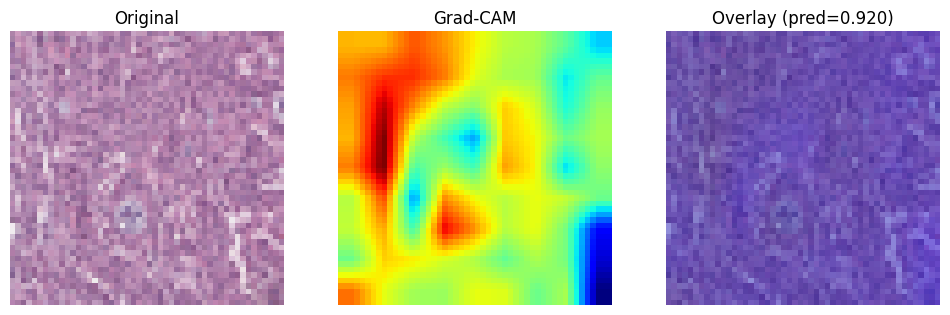

In [ ]:
for imgs, labels in test_gen:
    for i in range(len(labels)):
        if labels[i] == 1: #cancer
            img = imgs[i]
            true_label = labels[i]
            break
    break

# prepare the image for model input and generate a prediction, the output is the
# model's estimated probablity of cancer
img_array = np.expand_dims(img, axis=0)
pred = baseline_model.predict(img_array)[0][0]

heatmap = make_gradcam_heatmap(
    img_array, baseline_model, last_conv_layer_name
)

heatmap_resized = cv2.resize(heatmap, (50, 50))
heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)
overlay = cv2.addWeighted(
    np.uint8(255 * img), 0.6,
    heatmap_color, 0.4, 0
)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM")
plt.imshow(heatmap_resized, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"Overlay (pred={pred:.3f})")
plt.imshow(overlay)
plt.axis("off")

plt.show()


### Interpretation

The model predicts a high probability of cancer for this image.
The Grad-CAM heatmap highlights localized regions rather than the entire image,
indicating that the model is focusing on specific tissue patterns.
This suggests the model is learning meaningful visual features.

